# Alpha-Beta Pruning Demo

Minimax assumes that MAX chooses the highest utility and MIN chooses the lowest. Alpha-beta pruning returns the same root value while skipping branches that cannot change the decision.

This notebook uses NetworkX and Matplotlib to show the recursive calls. Run the cells in order. Leaf utilities are always measured from MAX's perspective.


## Imports

The directed graph stores parent-to-child edges; Matplotlib displays it after each recursive call. The search itself uses the supplied child lists, not a NetworkX search routine.


In [ ]:
# alpha beta pruning demo

import networkx as nx
import matplotlib.pyplot as plt




## Tree, Drawing, and Search

The methods stay in one cell because Python requires a class definition to be a complete block. Read the class in four parts:

1. **Initialization:** `__init__` stores the child lists and leaf utilities, creates dictionaries for backed-up values and bounds, then calls `create_tree`.
2. **Structure:** <code>create_tree</code> assigns depths recursively, places nodes by level, and adds graph edges. The first dictionary key is treated as the root; the input must be an acyclic tree.
3. **Drawing:** <code>draw_tree</code> colors the current node red. Node labels contain stored values; edge labels show the bounds passed into an explored child. Unvisited edges display default infinite bounds, not an explicit pruning marker.
4. **Recursion:** <code>alpha_beta_pruning</code> returns a leaf's utility, or alternates between maximizing and minimizing child values. MAX raises <code>alpha</code>, MIN lowers <code>beta</code>, and <code>beta <= alpha</code> stops the remaining siblings.

**Meaning of the bounds:** alpha is the best lower bound MAX can already secure on the current search path; beta is the best upper bound MIN can already enforce. Once the interval closes, exploring additional siblings cannot improve the ancestor's choice.


In [ ]:
class AlphaBetaTree:
    def __init__(self, tree_structure, values):
        self.tree = nx.DiGraph()
        self.tree_structure = tree_structure
        self.values = values
        self.node_values = {}
        self.positions = {}
        self.alpha_beta_edges = {}
        self.create_tree()

    def create_tree(self):
        levels = {}

        def assign_levels(node, depth=0):
            if node not in levels:
                levels[node] = depth
            for child in self.tree_structure.get(node, []):
                assign_levels(child, depth + 1)

        root = list(self.tree_structure.keys())[0]
        assign_levels(root)

        level_widths = {}
        for depth in levels.values():
            if depth not in level_widths:
                level_widths[depth] = 0
                level_widths[depth] += 1

        level_positions = {depth: 0 for depth in level_widths}
        self.positions = {}
        for node in sorted(levels, key=lambda x: (levels[x], x)):
            depth = levels[node]
            self.positions[node] = (level_positions[depth], -depth)
            level_positions[depth] += 1

        for node, children in self.tree_structure.items():
            self.tree.add_node(node)
            for child in children:
                self.tree.add_edge(node, child)

        # set all leaf nodes values
        for node in self.tree.nodes():
            if node in self.values:
                self.node_values[node] = self.values[node]

    def draw_tree(self, highlight_node=None):
        labels = {
            node: f"{node}\n{self.node_values.get(node, '')}"
            for node in self.tree.nodes()
        }
        edge_labels = {
            edge: f"({self.alpha_beta_edges.get(edge, (-float('inf'), float('inf')))[0]}, {self.alpha_beta_edges.get(edge, (-float('inf'), float('inf')))[1]})"
            for edge in self.tree.edges()
        }
        # print(self.alpha_beta_edges)
        colors = [
            "red" if node == highlight_node else "lightblue"
            for node in self.tree.nodes()
        ]
        nx.draw(
            self.tree,
            self.positions,
            with_labels=True,
            labels=labels,
            node_color=colors,
            node_size=2000,
            font_size=10,
        )
        nx.draw_networkx_edge_labels(
            self.tree, self.positions, edge_labels=edge_labels, font_size=8
        )
        plt.show()

    def alpha_beta_pruning(
        self, node, alpha=-float("inf"), beta=float("inf"), maximizing=True
    ):
        self.draw_tree(highlight_node=node)
        if node in self.values:
            self.node_values[node] = self.values[node]
            return self.values[node]

        if maximizing:
            value = -float("inf")
            for child in self.tree_structure[node]:
                # update alpha_beta_edges
                self.alpha_beta_edges[(node, child)] = (alpha, beta)
                value = max(value, self.alpha_beta_pruning(child, alpha, beta, False))
                alpha = max(alpha, value)
                if beta <= alpha:
                    break  # Prune
        else:
            value = float("inf")
            for child in self.tree_structure[node]:
                # update alpha_beta_edges
                self.alpha_beta_edges[(node, child)] = (alpha, beta)
                value = min(value, self.alpha_beta_pruning(child, alpha, beta, True))
                beta = min(beta, value)
                if beta <= alpha:
                    break  # Prune

        self.node_values[node] = value
        return value




## Define a Small Game Tree

A is MAX; B and C are MIN. The left subtree has leaves 3 and 5, so B returns 3. Before running the code, decide whether both leaves under C need to be visited once A can already obtain 3.

The child-list order determines the search order. All terminal nodes must have entries in <code>values</code>.


In [ ]:
# Example tree structure
tree_structure = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F", "G"],
    "D": [],
    "E": [],
    "F": [],
    "G": [],
}

values = {"D": 3, "E": 5, "F": 2, "G": 9}



## Run the Trace

The expected call order is A, B, D, E, C, F. B returns 3, raising A's alpha to 3. At C, F yields 2, lowering beta to 2. Since 2 is no greater than 3, G is skipped. The printed root value is **3**.

The whole tree remains visible even when a branch is not searched. A picture is drawn on entry to a call, before that call backs up its result, so its label can still be blank. The last printed value is the final answer.


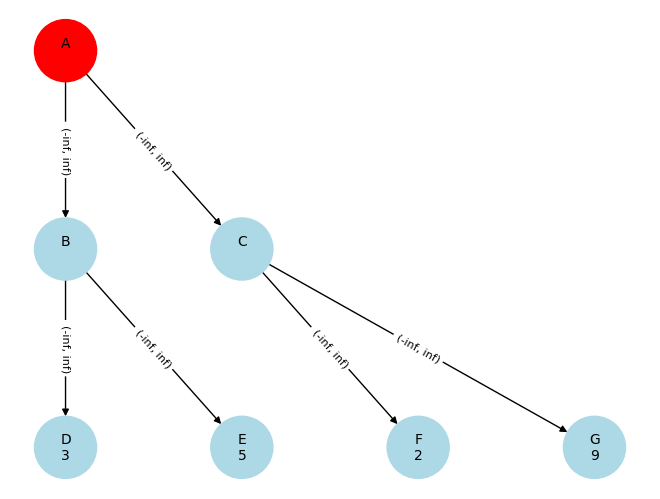

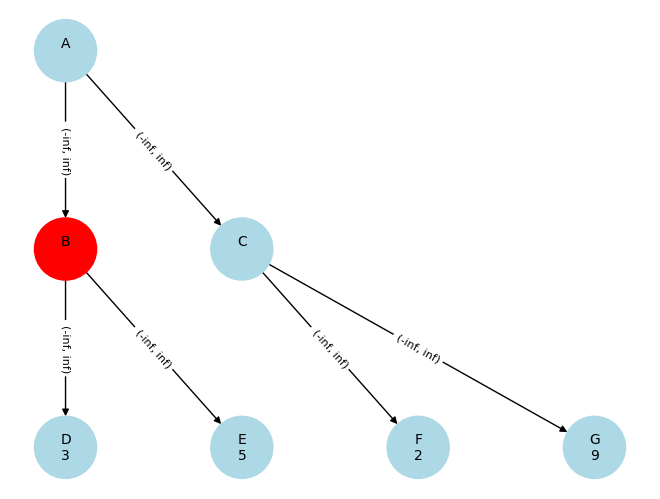

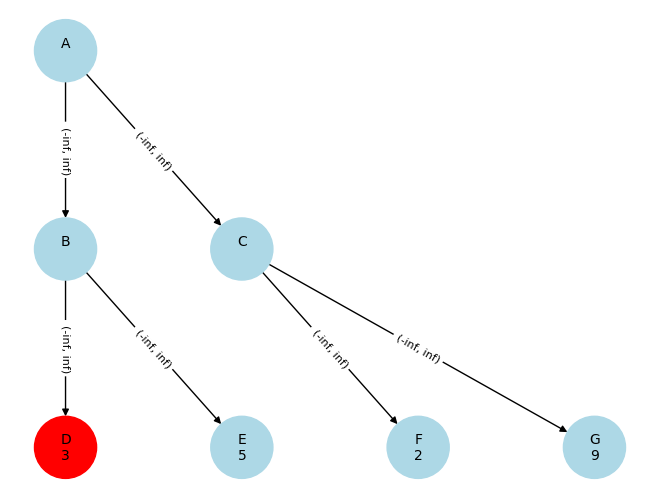

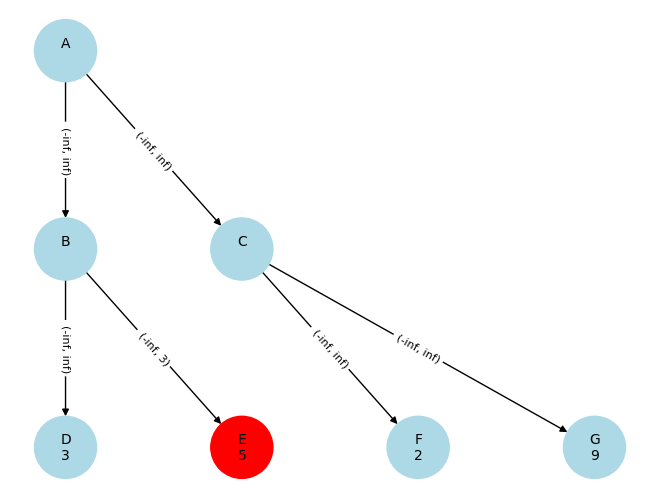

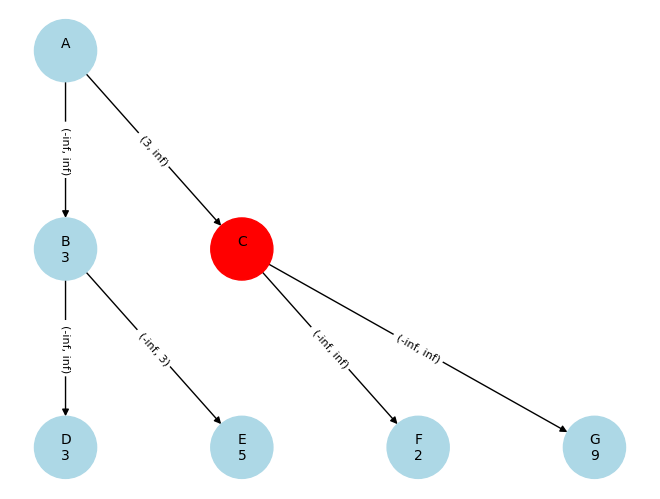

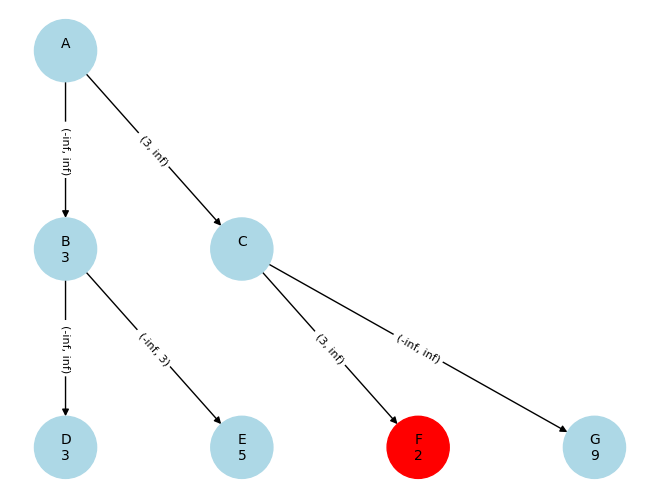

3


In [ ]:
alpha_beta_demo = AlphaBetaTree(tree_structure, values)
print(alpha_beta_demo.alpha_beta_pruning("A"))

## Check the Pruning Decision

- Change G's value from 9 to 100. Why does the root value remain 3?
- Swap the order of C's children. Which additional recursive call appears?
- Compute the root value without pruning and compare it with the printed result.

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **MIN still selects 2 under C.** Changing G from 9 to 100 gives `C = min(2, 100) = 2`, while `B = min(3, 5) = 3`. A therefore remains `max(3, 2) = 3`. With the original child order, G is never evaluated because F already makes C no better than 2 for MAX.
2. **G is now visited as well.** Searching C's children in the order G, F first obtains 9. C's beta is then 9, still greater than the inherited alpha of 3, so F must also be checked. The full call order becomes A, B, D, E, C, G, F. The root value stays 3, but no leaf is skipped.
3. **Ordinary minimax also returns 3.** Evaluate both children of each MIN node: `B = min(3, 5) = 3` and `C = min(2, 9) = 2`. The MAX root chooses `max(3, 2) = 3`. Alpha-beta obtains this same answer without visiting G in the original ordering.

</details>

**Takeaway:** move ordering changes the amount of pruning, not the minimax answer. A value returned from a cutoff can be a bound rather than the exact value of that subtree.
